# 🧠 Supervised Contrastive Learning (SupCon)

**Part II · Embedding Architectures & Similarity Learning**

---

## 👤 Instructor

**Ing. Jesús Alan Hernández Galván**

📫 alanhernandezgalvan@icloud.com
🌐 [https://unlikeghost.github.io/](https://unlikeghost.github.io/)

---

## 🗺️ Progreso del curso

1. CNN: The Feature Extractor ✅
2. **Embedding Architectures & Similarity Learning 📍**
3. The SupCon Pipeline (Scalability & Transfer)

---

## 🎯 Objetivo del módulo
Construir la infraestructura de **Metric Learning** necesaria para proyectar datos biomédicos en un espacio latente organizado por similitud.

Este módulo marca la transición de la arquitectura LeNet tradicional hacia sistemas de **pesos compartidos (Siamese Networks)**. Aprenderemos a transformar imágenes en puntos dentro de un espacio vectorial (**Embeddings**) donde la cercanía geométrica es forzada por etiquetas de clase. El enfoque será entender cómo la función de pérdida (Contrastive Loss) actúa como un arquitecto del espacio latente, preparando el terreno para el entrenamiento a gran escala y la transferencia de conocimiento de la Parte III.


In [1]:
import sys

def check_environment():
    if 'google.colab' in sys.modules:
        print("Entorno: Google Colab ☁️")

        from IPython import get_ipython
        ipython = get_ipython()
        if ipython:
            print("Instalando dependencias necesarias...")
            ipython.run_line_magic('pip', 'install --upgrade umap-learn numba')

        return "colab"
    else:
        print("Entorno: Local / Jupyter Notebook 💻")
        return "local"

env = check_environment()

Entorno: Local / Jupyter Notebook 💻


In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
if env == 'local':
    import os
    project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
    data_path = os.path.join(project_root, "data")
    models_path = os.path.join(project_root, "models")

else:
    data_path = "./data"
    models_path = "./models"

## Librerias

In [4]:
import umap
import torch
import random
import torchvision

import numpy as np
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.transforms as transforms

from torchsummary import summary
from sklearn.metrics import confusion_matrix

In [5]:
from src.models import LeNet5Encoder
from src.plot_data import show_batch, show_features, plot_latent_space_3d, plot_latent_space_2d, show_siamese_batch
from src.datasets import ContrastiveLearningDataset
from src.losses import ContrastiveLoss

## 🔒 Semilla para reproducibilidad

In [6]:
seed: int = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

## ⚡ Optimización de Aceleración por Hardware (CUDA/cuDNN)

### 🚀 Verificar uso de GPU (si está disponible)

In [7]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
    )
print(f"Status: System ready on {device}")

Status: System ready on cuda


In [8]:
if device == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.allow_tf32 = True

## 🧪 Implementación

### 📦 Carga y preprocesamiento de datos

A diferencia de la clasificación convencional, donde el dataset CIFAR-10 nos entrega una imagen y su categoría correspondiente para que la red aprenda a "nombrar" objetos, el aprendizaje contrastivo requiere un enfoque distinto. Para entrenar una arquitectura siamesa, necesitamos que el modelo aprenda a extraer representaciones que le permitan comparar similitudes en lugar de solo asignar etiquetas.

Dado que CIFAR-10 no está estructurado de esta manera, hemos implementado un DataLoader personalizado encargado de transformar el flujo de datos en un sistema de pares. En este esquema, el modelo recibe dos imágenes simultáneamente junto con un indicador binario: un valor de 1 si ambas imágenes pertenecen a la misma clase (par positivo) y un valor de 0 si pertenecen a categorías diferentes (par negativo). Este cambio en la preparación de los datos es lo que permite que la red pase de un aprendizaje basado en etiquetas a uno basado en la discriminación y asociación de rasgos visuales.

In [9]:
batch_size: int = 512

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Resize(size=(32, 32)),
     transforms.Normalize(
         mean=(0.485, 0.456, 0.406),
         std=(0.229, 0.224, 0.225)
         ), # ImageNet values
     ]
)

classes: tuple = (
    'plane', 'car', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
)

In [10]:
train_data = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True,
)
test_data = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
)

train_dataset = ContrastiveLearningDataset(
    dataset=train_data,
    transform=transform
)
test_dataset = ContrastiveLearningDataset(
    dataset=test_data,
    transform=transform
)

In [11]:

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
)

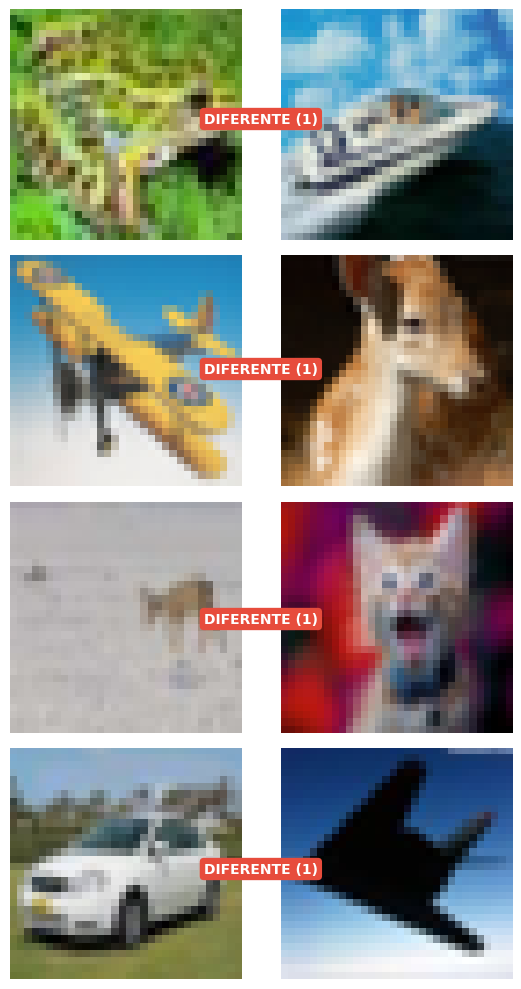

In [12]:
show_siamese_batch(
    train_loader,
    n_pairs=4
)

### 🧠 Siamese Architecture: Similarity Learning

![Siamese network](https://b2633864.smushcdn.com/2633864/wp-content/uploads/2020/11/keras_siamese_networks_process.png?lossy=2&strip=1&webp=1)


Esta arquitectura utiliza ramas gemelas con pesos compartidos para aprender a comparar en lugar de clasificar. En este paradigma, la red actúa como un cartógrafo que proyecta imágenes en un espacio geométrico donde la distancia dicta la relación semántica: si dos objetos se parecen, sus vectores deben colisionar; si son distintos, deben repelerse.

Es la base de tecnologías como FaceID y sistemas de recomendación visual, ya que permite extraer Embeddings (huellas digitales numéricas) que capturan la esencia de los datos sin depender de etiquetas rígidas. Este "mapeo inteligente" es el puente técnico hacia el aprendizaje autosupervisado, donde la red aprende a organizarse sola explorando la estructura interna de las imágenes.

In [13]:
model = LeNet5Encoder().to(device)
print(model)
summary(model, input_size=(3, 32, 32))

LeNet5Encoder(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (projector): Sequential(
    (0): Linear(in_features=400, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             456
              ReLU-2            [-1, 6, 28, 28]               0
         AvgPool2d-3            [-1, 6, 14, 14]               0
            Conv2d-4           [-1, 16, 10, 10]           2,416
              ReLU-5           [-1, 16, 10, 10]               0
         AvgPool2d-6             [-1, 16, 5, 5]               0
   

### ⚙️ Proceso de entrenamiento

In [14]:
num_epochs: int = 50
model = LeNet5Encoder().to(device)
model = torch.compile(model)

criterion = ContrastiveLoss(margin=1.1)
optimizer = optim.Adam(model.parameters(), lr=3e-3)

In [15]:
import torch.nn.functional as F

train_loss = []
train_sim_pos = []
train_sim_neg = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_sim_pos = 0.0
    running_sim_neg = 0.0

    # Contadores para promediar correctamente si un batch no tiene de ambos tipos
    pos_count = 0
    neg_count = 0

    for img1, img2, target in train_loader:
        img1, img2, target = img1.to(device), img2.to(device), target.to(device)
        target = target.squeeze()

        optimizer.zero_grad()
        emb1 = model(img1)
        emb2 = model(img2)

        loss = criterion(emb1, emb2, target)
        loss.backward()
        optimizer.step()

        # --- Cálculo de Distancia Euclidiana ---
        with torch.no_grad():
            distances = F.pairwise_distance(emb1, emb2)

            # 0 = Misma clase (Positivos), 1 = Diferente clase (Negativos)
            pos_mask = (target == 0)
            neg_mask = (target == 1)

            if pos_mask.any():
                running_sim_pos += distances[pos_mask].mean().item()
                pos_count += 1
            if neg_mask.any():
                running_sim_neg += distances[neg_mask].mean().item()
                neg_count += 1

        running_loss += loss.item()

    # Métricas finales de la época
    epoch_loss = running_loss / len(train_loader)
    epoch_sim_pos = running_sim_pos / pos_count if pos_count > 0 else 0
    epoch_sim_neg = running_sim_neg / neg_count if neg_count > 0 else 0

    train_loss.append(epoch_loss)
    train_sim_pos.append(epoch_sim_pos)
    train_sim_neg.append(epoch_sim_neg)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f} | Dist+: {epoch_sim_pos:.4f} | Dist-: {epoch_sim_neg:.4f}")

Epoch [1/50] Loss: 0.1510 | Dist+: 0.4938 | Dist-: 0.5822
Epoch [2/50] Loss: 0.1306 | Dist+: 0.4609 | Dist-: 0.6270
Epoch [3/50] Loss: 0.1275 | Dist+: 0.4540 | Dist-: 0.6423
Epoch [4/50] Loss: 0.1231 | Dist+: 0.4452 | Dist-: 0.6585
Epoch [5/50] Loss: 0.1214 | Dist+: 0.4416 | Dist-: 0.6627
Epoch [6/50] Loss: 0.1191 | Dist+: 0.4402 | Dist-: 0.6757
Epoch [7/50] Loss: 0.1200 | Dist+: 0.4375 | Dist-: 0.6696
Epoch [8/50] Loss: 0.1179 | Dist+: 0.4321 | Dist-: 0.6747
Epoch [9/50] Loss: 0.1160 | Dist+: 0.4266 | Dist-: 0.6838
Epoch [10/50] Loss: 0.1154 | Dist+: 0.4254 | Dist-: 0.6863
Epoch [11/50] Loss: 0.1146 | Dist+: 0.4244 | Dist-: 0.6883
Epoch [12/50] Loss: 0.1151 | Dist+: 0.4309 | Dist-: 0.6934
Epoch [13/50] Loss: 0.1140 | Dist+: 0.4230 | Dist-: 0.6921
Epoch [14/50] Loss: 0.1114 | Dist+: 0.4194 | Dist-: 0.7060
Epoch [15/50] Loss: 0.1126 | Dist+: 0.4190 | Dist-: 0.6984
Epoch [16/50] Loss: 0.1126 | Dist+: 0.4213 | Dist-: 0.7003
Epoch [17/50] Loss: 0.1105 | Dist+: 0.4166 | Dist-: 0.7083
Epoch 

In [28]:
torch.save(
    model.state_dict(),
    os.path.join(models_path, "lenet5_siamese.pth")
)

### 📊 Métricas de entrenamiento y validación

#### 📊 Entrenamiento

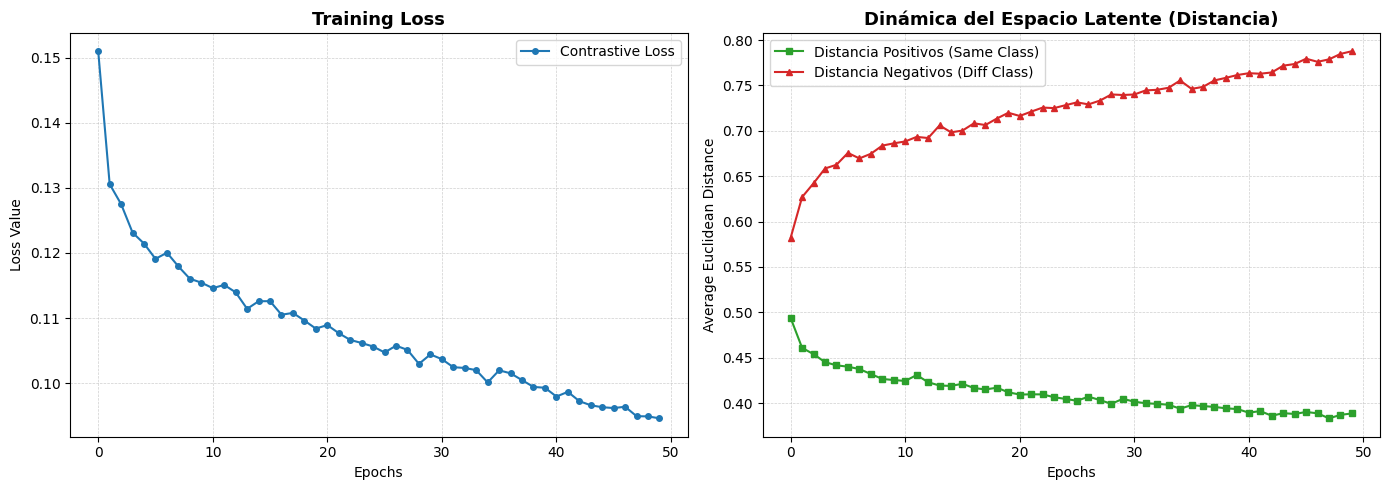

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(train_loss, label='Contrastive Loss', color='#1f77b4', marker='o', markersize=4, linewidth=1.5)
axs[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss Value')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)


axs[1].plot(train_sim_pos, label='Distancia Positivos (Same Class)', color='#2ca02c', marker='s', markersize=4, linewidth=1.5)
axs[1].plot(train_sim_neg, label='Distancia Negativos (Diff Class)', color='#d62728', marker='^', markersize=4, linewidth=1.5)

axs[1].set_title('Dinámica del Espacio Latente (Distancia)', fontsize=13, fontweight='bold')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Average Euclidean Distance')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### 📊 Validación

In [18]:
model.eval()
all_preds = []
all_labels = []

# Umbral de distancia: menor a esto es IGUAL (0)
threshold = 0.5

with torch.no_grad():
    for img1, img2, target in test_loader:
        img1, img2, target = img1.to(device), img2.to(device), target.to(device)

        # 1. Obtener embeddings
        emb1 = model(img1)
        emb2 = model(img2)

        # 2. Distancia euclidiana
        distancia = F.pairwise_distance(emb1, emb2)

        # 3. Predicción: 0 si son iguales (dist < umbral), 1 si son diferentes
        # La condición (dist >= threshold) marca como 1 los que superan el umbral
        predicted = (distancia >= threshold).int()

        # 4. Etiquetas reales (0: Igual, 1: Diferente)
        target_labels = target.view(-1).int()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(target_labels.cpu().numpy())

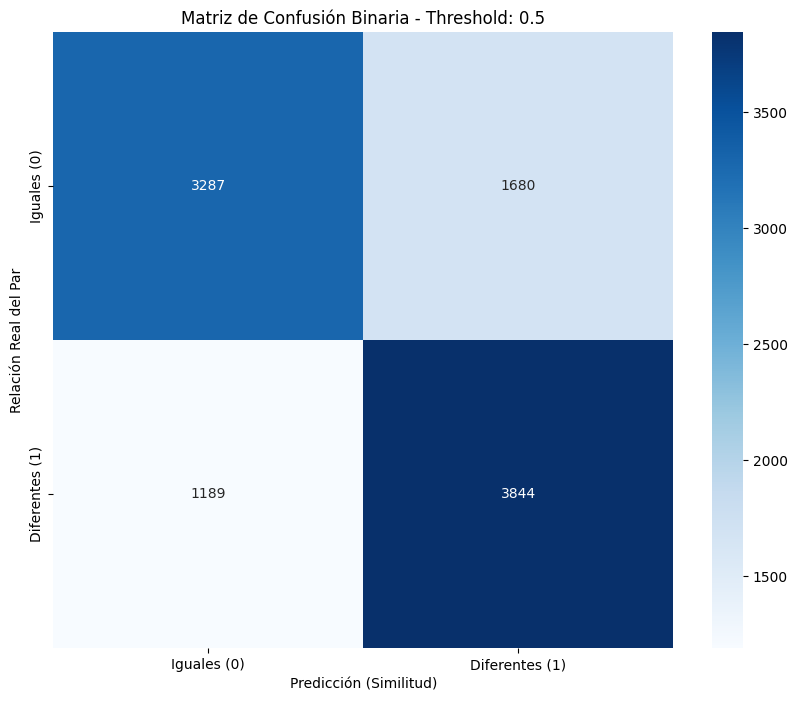

In [19]:
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Iguales (0)', 'Diferentes (1)'],
            yticklabels=['Iguales (0)', 'Diferentes (1)'])

plt.xlabel('Predicción (Similitud)')
plt.ylabel('Relación Real del Par')
plt.title(f'Matriz de Confusión Binaria - Threshold: {threshold}')
plt.show()

### 🔍 Visualización de features

#### 🧩 Feature Maps

In [20]:
model.eval()

images_batch, _, labels_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

images_batch = images_batch[0:5, :, :, :]

with torch.no_grad():
    # Extraer features de la PRIMERA capa (índice 0 es Conv1, índice 1 es ReLU)
    # Pasamos solo por las primeras 2 capas del bloque
    features_conv1 = model.feature_extractor[:2](images_batch)

    # Extraer features de la SEGUNDA capa (índice 3 es Conv2, índice 4 es ReLU)
    # Pasamos por las primeras 5 capas del bloque
    features_conv2 = model.feature_extractor[:5](images_batch)


images_np = images_batch.cpu().numpy()
feat1_np = features_conv1.cpu().numpy() # Forma: (32, 6, 28, 28)
feat2_np = features_conv2.cpu().numpy() # Forma: (32, 16, 10, 10)

feat1_np.shape, feat2_np.shape

((5, 6, 28, 28), (5, 16, 10, 10))

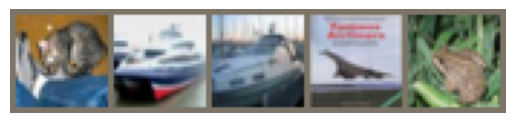

Canal 0


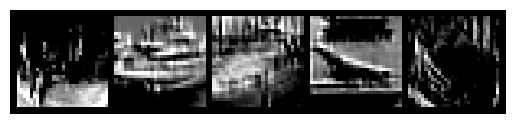

Canal 1


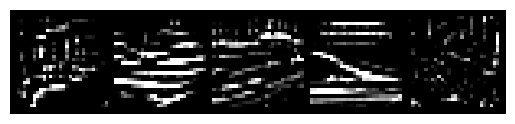

Canal 2


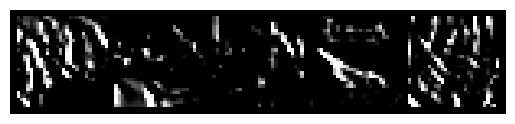

Canal 3


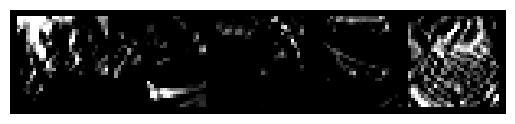

Canal 4


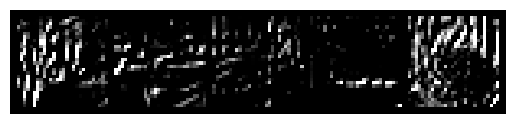

Canal 5


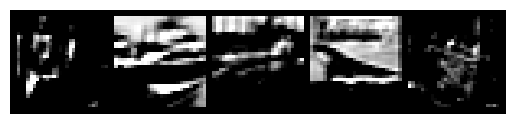

Canal 0


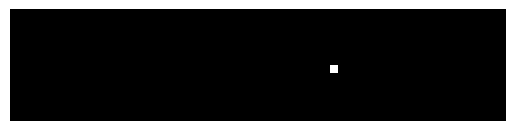

Canal 1


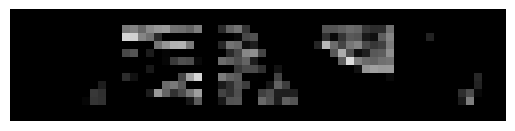

Canal 2


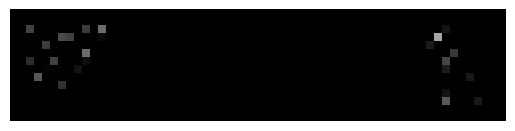

Canal 3


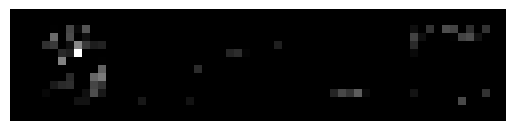

Canal 4


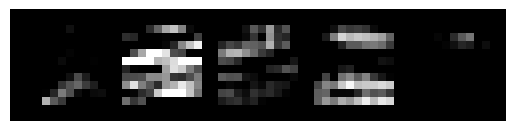

Canal 5


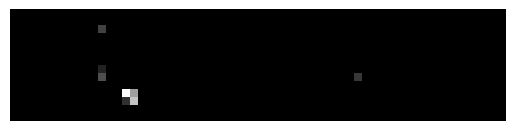

Canal 6


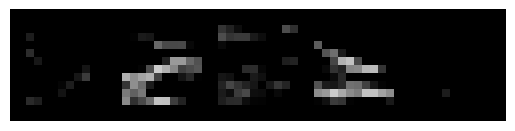

Canal 7


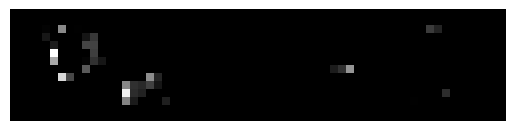

Canal 8


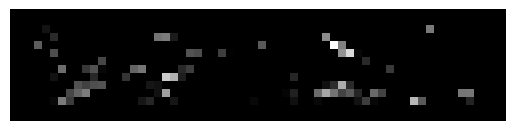

Canal 9


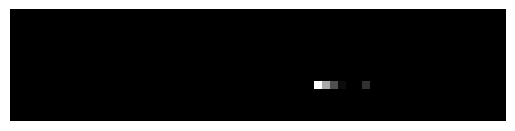

Canal 10


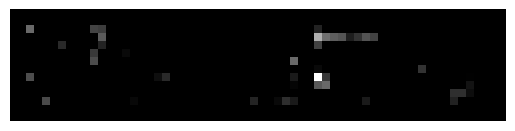

Canal 11


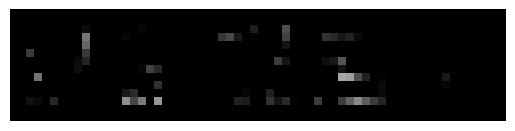

Canal 12


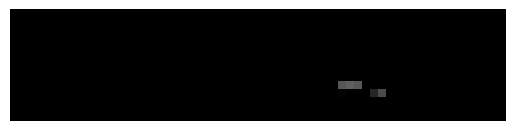

Canal 13


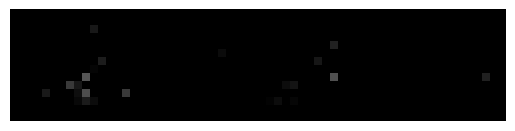

Canal 14


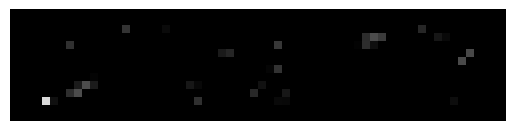

Canal 15


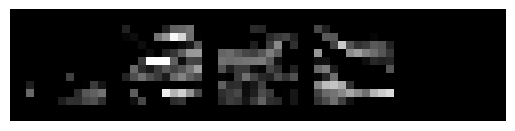

In [21]:
show_batch(
    torchvision.utils.make_grid(images_batch.to('cpu')),
)

for i in range(0, 6):
  print(f"Canal {i}")
  show_features(features_conv1, filter_index=i)

for i in range(0, 16):
  print(f"Canal {i}")
  show_features(features_conv2, filter_index=i)

#### 🧩 Proyección del espacio latente

In [22]:
# Creamos un loader sencillo que solo dé (imagen, clase_real)

simple_test_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
    transform=transform
)
simple_test_loader = torch.utils.data.DataLoader(
    simple_test_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

In [23]:
model.eval()

all_embeddings = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in simple_test_loader:
        images = images.to(device)

        # Extraemos el embedding
        embedding = model(images)

        all_embeddings.append(embedding.cpu().numpy())
        all_labels.append(labels.numpy())

# Concatenamos todo en un solo array gigante
all_features = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

all_features.shape, all_labels.shape

((10000, 128), (10000,))

##### 🧩 3D

In [24]:
umap_embeddings = umap.UMAP(n_components=3).fit_transform(all_features)
umap_embeddings.shape

(10000, 3)

In [25]:
plot_latent_space_3d(
    umap_embeddings,
    all_labels,
    classes
)

##### 🧩 2D

In [26]:
umap_embeddings_2d = umap.UMAP(n_components=2).fit_transform(all_features)
umap_embeddings_2d.shape

(10000, 2)

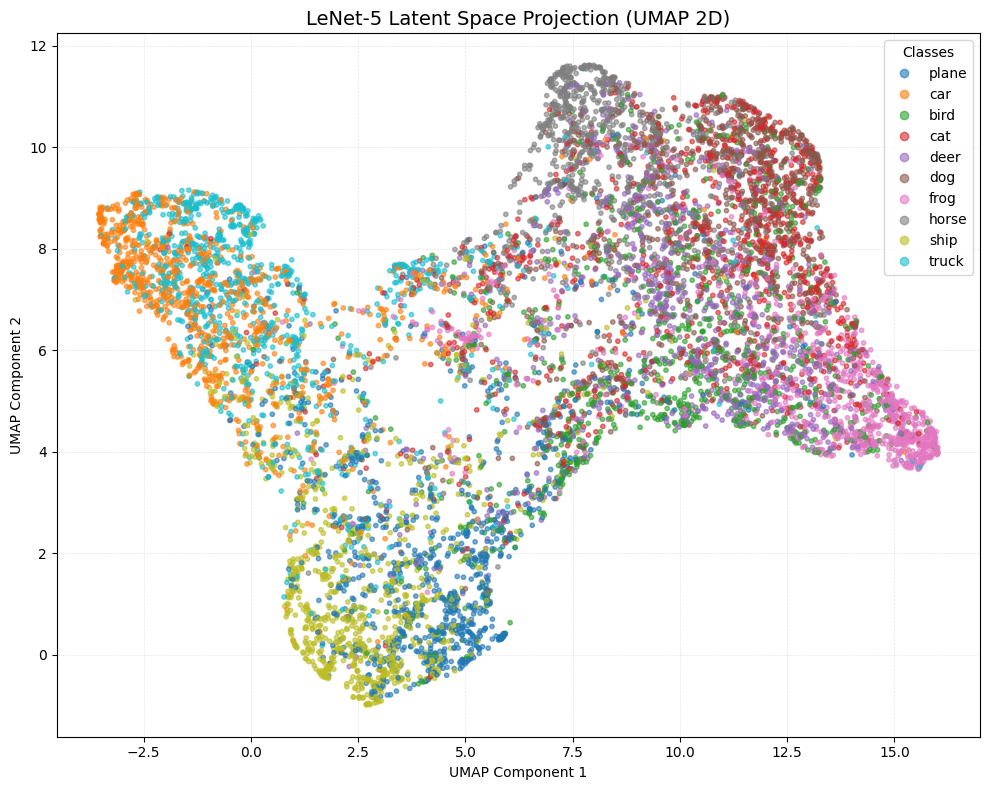

In [27]:
plot_latent_space_2d(
    umap_embeddings_2d,
    all_labels,
    classes
)